In [ ]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from src.community_detection import CommunityDetection
from src.ansatze import Ansatz
from src.simulator import QuimbSimulator
from src.optimizer import COBYLA
from src.lvqe import LayerVQE

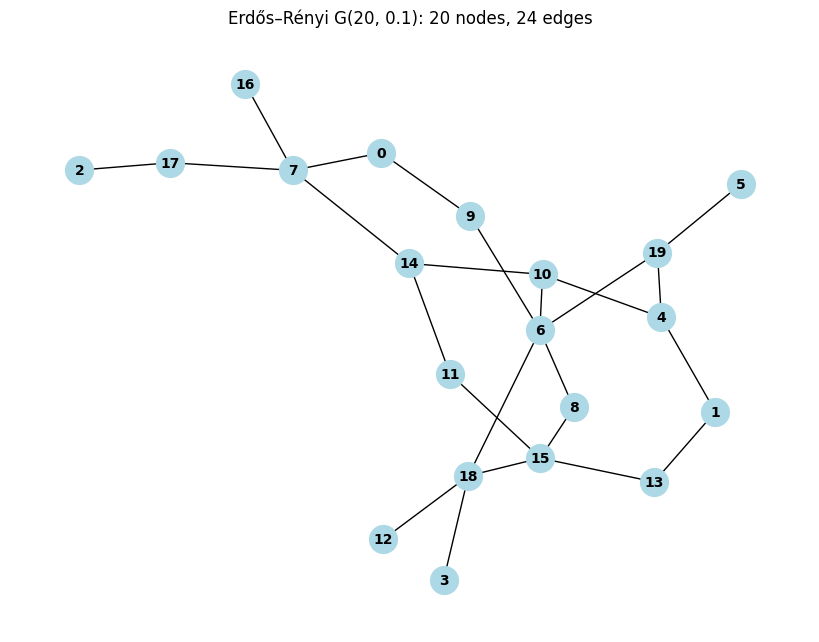

In [2]:
#Erdős–Rényi random graph G(n, p)
G = nx.gnp_random_graph(n=20, p=0.1, seed=42)

#if it is not connected, try again
seed = 42
while not nx.is_connected(G):
    seed += 1
    G = nx.gnp_random_graph(n=20, p=0.1, seed=seed)

# plot
plt.figure(figsize=(8, 6))
pos = nx.spring_layout(G, seed=42)
nx.draw(G, pos, with_labels=True, node_color='lightblue', 
        node_size=400, font_size=10, font_weight='bold')
plt.title(f"Erdős–Rényi G(20, 0.1): {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")
plt.show()

In [8]:

# create the problem — k=4 communities
# this means N=2 bits per node, so 40 qubits total
k = 4
problem = CommunityDetection(G, k)
print(f"\nn_qubits: {problem.n_qubits}")
print(f"n_terms: {len(problem.terms)}")

# for 20 nodes, brute force is infeasible — use Louvain heuristic
# (best_known_value will switch to Louvain automatically if n_nodes > 12)
best_known = problem.best_known_value()
print(f"best known modularity (Louvain): {best_known:.4f}")

# run L-VQE
sim = QuimbSimulator()
lvqe = LayerVQE(
    problem=problem,
    simulator=sim,
    optimizer_class=COBYLA,
    n_layers=2,
    k_per_layer=200,
    k_final=3000,
    use_sampling=False
)

result = lvqe.run()

print(f"\nFinal approximation ratio: {result['final_approx_ratio']:.4f}")

# plot the convergence
plt.figure(figsize=(8, 5))
plt.plot(result['history']['layer'], result['history']['approx_ratio'], 
         'o-', linewidth=2, markersize=10)
plt.xlabel('Layer')
plt.ylabel('Approximation Ratio')
plt.title('L-VQE convergence on Erdős–Rényi G(20, 0.1)')
plt.grid(True, alpha=0.3)
plt.xticks(result['history']['layer'])
plt.show()


n_qubits: 40
n_terms: 1600
best known modularity (Louvain): 0.4314
Starting L-VQE: 2 layers, 200 iter/layer, 3000 final iter
Mode: exact expectation

Layer 0: 

layer 0: energy=-0.3723, approx_ratio=+0.8526

Layer 1 — 200 iterations (before convergence)


KeyboardInterrupt: 

In [3]:
import time

k = 4
problem = CommunityDetection(G, k)
print(f"n_qubits: {problem.n_qubits}, n_terms: {len(problem.terms)}")

sim = QuimbSimulator()
ansatz = Ansatz(problem.n_qubits)

cost_fn = lambda p: sim.expectation(p, ansatz, problem)

# Layer 0 only, monitor with progress bar
print("\nRunning COBYLA on Layer 0 (40 parameters)...")
t0 = time.time()
opt = COBYLA(max_iter=200)
best_params, best_energy = opt.optimise(ansatz.params.copy(), cost_fn)
elapsed = time.time() - t0

print(f"\nFinal energy: {best_energy:+.4f}")
print(f"Total time: {elapsed:.1f}s ({elapsed/60:.1f} min)")
print(f"Total evaluations: {opt.eval_count}")
print(f"Average time per eval: {elapsed/opt.eval_count:.2f}s")

# approximation ratio
best_known = problem.best_known_value()
ratio = problem.approximation_ratio(best_energy, best_known)
print(f"Approximation ratio: {ratio:.4f}")

n_qubits: 40, n_terms: 571

Running COBYLA on Layer 0 (40 parameters)...


COBYLA:  45%|████▌     | 200/440 [04:01<04:50,  1.21s/it, best_E=-0.3625]

Total evaluations: 200

Final energy: -0.3625
Total time: 242.0s (4.0 min)
Total evaluations: 200
Average time per eval: 1.21s
Approximation ratio: 0.8403
